In [2]:
!pip install torch torchvision matplotlib -q

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torchvision.datasets import CIFAR10
from torch.utils.data import Subset, DataLoader
import matplotlib.pyplot as plt
import numpy as np
import os

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f" Using device: {device}")

 Using device: cuda


In [3]:
# Our 5 grocery classes
SELECTED = {
    3: "Fresh Produce",
    5: "Pet Food",
    2: "Organic Items",
    7: "Farm Products",
    9: "Packaged Goods",
}

# Map original labels to 0-4
LABEL_MAP = {orig: new for new, orig in enumerate(SELECTED.keys())}
CLASS_NAMES = list(SELECTED.values())

# Transforms with augmentation for training
train_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(64, padding=4),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

test_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Download data
print("⬇ Loading dataset...")
trainset = CIFAR10(root='./data', train=True,  download=True, transform=train_transform)
testset  = CIFAR10(root='./data', train=False, download=True, transform=test_transform)

# Filter to our 5 classes
train_indices = [i for i, (_, l) in enumerate(trainset) if l in SELECTED]
test_indices  = [i for i, (_, l) in enumerate(testset)  if l in SELECTED]

train_subset = Subset(trainset, train_indices)
test_subset  = Subset(testset,  test_indices)

# DataLoaders
train_loader = DataLoader(train_subset, batch_size=64, shuffle=True,  num_workers=2)
test_loader  = DataLoader(test_subset,  batch_size=64, shuffle=False, num_workers=2)

print(f"Training batches: {len(train_loader)}")
print(f"Test batches:     {len(test_loader)}")
print(f"Classes: {CLASS_NAMES}")

⬇ Loading dataset...


100%|██████████| 170M/170M [06:09<00:00, 461kB/s]


Training batches: 391
Test batches:     79
Classes: ['Fresh Produce', 'Pet Food', 'Organic Items', 'Farm Products', 'Packaged Goods']


In [5]:
class GroceryClassifier(nn.Module):
    def __init__(self, num_classes=5):
        super(GroceryClassifier, self).__init__()

        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.MaxPool2d(2, 2), nn.Dropout2d(0.25),

            # Block 2
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2, 2), nn.Dropout2d(0.25),

            # Block 3
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d(2, 2), nn.Dropout2d(0.25),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 8 * 8, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model = GroceryClassifier(num_classes=5).to(device)
print(" Model built!")
print(f"   Total parameters: {sum(p.numel() for p in model.parameters()):,}")

 Model built!
   Total parameters: 2,238,757


In [6]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

EPOCHS = 10
train_losses, test_losses, test_accuracies = [], [], []

print(" Training started...\n")

for epoch in range(EPOCHS):
    # --- Training ---
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        # Remap labels to 0-4
        labels = torch.tensor([LABEL_MAP[l.item()] for l in labels])
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    # --- Evaluation ---
    model.eval()
    correct, total, test_loss = 0, 0, 0.0
    with torch.no_grad():
        for images, labels in test_loader:
            labels = torch.tensor([LABEL_MAP[l.item()] for l in labels])
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            test_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    acc = 100 * correct / total
    avg_train_loss = running_loss / len(train_loader)
    avg_test_loss  = test_loss  / len(test_loader)

    train_losses.append(avg_train_loss)
    test_losses.append(avg_test_loss)
    test_accuracies.append(acc)
    scheduler.step()

    print(f"Epoch [{epoch+1:2d}/{EPOCHS}] | "
          f"Train Loss: {avg_train_loss:.4f} | "
          f"Test Loss: {avg_test_loss:.4f} | "
          f"Accuracy: {acc:.2f}%")

print(f"\n Training complete! Best accuracy: {max(test_accuracies):.2f}%")

 Training started...

Epoch [ 1/10] | Train Loss: 1.3632 | Test Loss: 1.0714 | Accuracy: 57.02%
Epoch [ 2/10] | Train Loss: 1.1856 | Test Loss: 0.9918 | Accuracy: 57.28%
Epoch [ 3/10] | Train Loss: 1.1370 | Test Loss: 0.9507 | Accuracy: 60.12%
Epoch [ 4/10] | Train Loss: 1.1057 | Test Loss: 0.9170 | Accuracy: 62.46%
Epoch [ 5/10] | Train Loss: 1.0565 | Test Loss: 0.9081 | Accuracy: 63.46%
Epoch [ 6/10] | Train Loss: 1.0051 | Test Loss: 0.8369 | Accuracy: 66.68%
Epoch [ 7/10] | Train Loss: 0.9777 | Test Loss: 0.8021 | Accuracy: 67.66%
Epoch [ 8/10] | Train Loss: 0.9612 | Test Loss: 0.8038 | Accuracy: 68.30%
Epoch [ 9/10] | Train Loss: 0.9376 | Test Loss: 0.7761 | Accuracy: 68.88%
Epoch [10/10] | Train Loss: 0.9255 | Test Loss: 0.7655 | Accuracy: 69.52%

 Training complete! Best accuracy: 69.52%


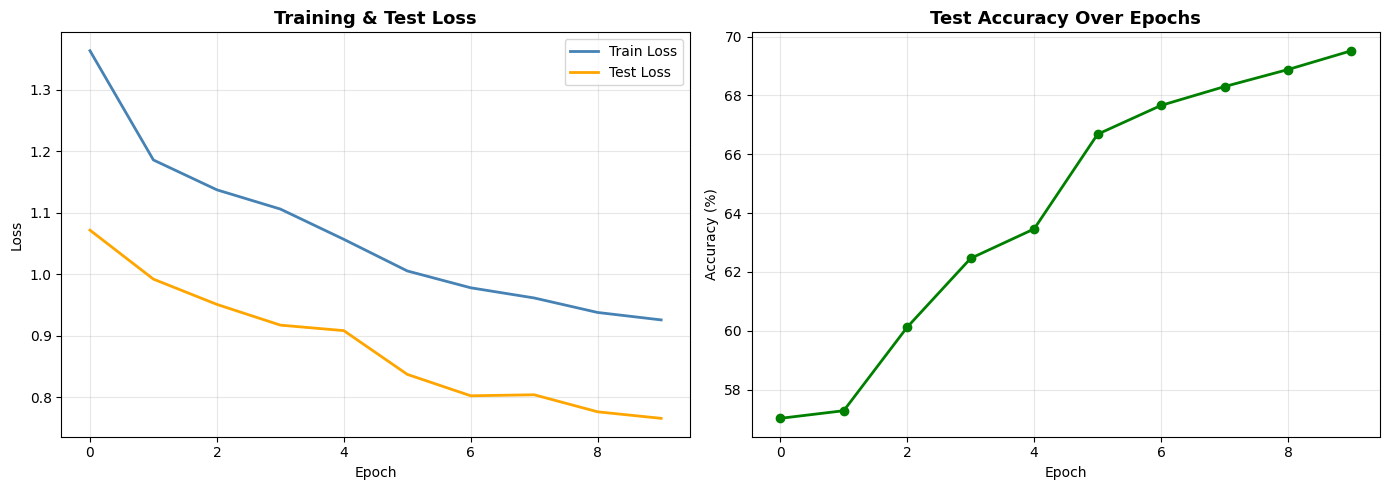

 Training curves saved!


In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss curve
ax1.plot(train_losses, label='Train Loss', color='steelblue', linewidth=2)
ax1.plot(test_losses,  label='Test Loss',  color='orange',    linewidth=2)
ax1.set_title('Training & Test Loss', fontsize=13, fontweight='bold')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Accuracy curve
ax2.plot(test_accuracies, color='green', linewidth=2, marker='o')
ax2.set_title('Test Accuracy Over Epochs', fontsize=13, fontweight='bold')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=100, bbox_inches='tight')
plt.show()
print(" Training curves saved!")

In [8]:
os.makedirs('models/trained', exist_ok=True)

torch.save({
    'model_state_dict': model.state_dict(),
    'class_names': CLASS_NAMES,
    'label_map': LABEL_MAP,
    'final_accuracy': test_accuracies[-1],
    'best_accuracy': max(test_accuracies),
}, 'models/trained/grocery_classifier.pth')

print(" Model saved to models/trained/grocery_classifier.pth")
print(f" Final Accuracy: {test_accuracies[-1]:.2f}%")
print(f" Best Accuracy:  {max(test_accuracies):.2f}%")


 Model saved to models/trained/grocery_classifier.pth
 Final Accuracy: 69.52%
 Best Accuracy:  69.52%
